# Gestion des comptes

In [2]:
import os
import shutil
import pandas as pd

from Fonction import *


In [3]:

from Fonction import *
from Classe import *

# INTERFACE de gestion de compte

In [5]:
import tkinter as tk
from tkinter import ttk, messagebox, filedialog, simpledialog
import os
from tkcalendar import DateEntry

In [6]:
# -------------------------
# Combobox avec autocomplétion
# -------------------------
class AutocompleteCombobox(ttk.Combobox):
    def set_completion_list(self, completion_list):
        """Charge une liste de valeurs uniques (insensible à la casse)"""
        clean_list = [str(x) for x in completion_list if pd.notna(x)]
        self._completion_list = sorted(set(clean_list), key=lambda v: v.lower())
        self._filtered_list = self._completion_list
        self["values"] = self._completion_list
        self.bind("<KeyRelease>", self._on_keyrelease)

    def _on_keyrelease(self, event):
        """Filtrer dynamiquement, insensible à la casse"""
        text = self.get().lower()
        if text == "":
            self._filtered_list = self._completion_list
        else:
            self._filtered_list = [v for v in self._completion_list if text in v.lower()]
        self["values"] = self._filtered_list


In [7]:
class ComptesTab(ttk.Frame):
    def __init__(self, parent, compta):
        super().__init__(parent)
        self.compta = compta
        self.combo_editor = None
        self._build_ui()
        self._refresh_table()

    def _build_ui(self):
        # Tableau
        self.tree = ttk.Treeview(
            self, columns=("Nom", "Etat", "Cumulé"), show="headings", height=12
        )
        self.tree.heading("Nom", text="Nom du compte")
        self.tree.heading("Etat", text="État")
        self.tree.heading("Cumulé", text="Cumulé (€)")

        self.tree.column("Nom", width=250, anchor=tk.W)
        self.tree.column("Etat", width=120, anchor=tk.CENTER)
        self.tree.column("Cumulé", width=120, anchor=tk.E)

        self.tree.pack(fill=tk.BOTH, expand=True, pady=10, padx=10)

        # Boutons
        frame_btn = tk.Frame(self)
        frame_btn.pack(pady=15)

        btn_ajouter = ttk.Button(frame_btn, text="Ajouter")
        btn_ajouter.grid(row=0, column=0, padx=10)
        btn_ajouter.bind("<Button-1>", lambda e: self._menu_ajouter(btn_ajouter))

        ttk.Button(frame_btn, text="Supprimer", command=self._supprimer).grid(row=0, column=1, padx=10)
        ttk.Button(frame_btn, text="Rafraîchir", command=self._refresh_table).grid(row=0, column=2, padx=10)

        # Edition directe
        self.tree.bind("<Button-1>", self._start_edit)

    def _refresh_table(self):
        for row in self.tree.get_children():
            self.tree.delete(row)

        for compte in self.compta.comptes:
            argent = Cummuler_Name(compte.compte_actif)["Ecart"][0]
            self.tree.insert("", tk.END, iid=compte.name,
                             values=(compte.name, compte.state, argent))

    def _menu_ajouter(self, bouton):
        menu = tk.Menu(self, tearoff=0)
        menu.add_command(label="Créer un fichier Excel", command=self._ajouter_creer_fichier)
        menu.add_command(label="Référencer un Excel existant", command=self._ajouter_excel_existant)

        x = bouton.winfo_rootx()
        y = bouton.winfo_rooty() + bouton.winfo_height()
        menu.post(x, y)

    def _ajouter_creer_fichier(self):
        fichier = filedialog.asksaveasfilename(
            title="Créer un fichier Excel",
            defaultextension=".xlsx",
            filetypes=[("Fichier Excel", "*.xlsx *.xls")]
        )
        if fichier:
            try:
                self.compta.ajouter_compte(fichier, etat="open")
                self._refresh_table()
                messagebox.showinfo("Succès", f"Compte créé et ajouté : {os.path.basename(fichier)}")
            except Exception as e:
                messagebox.showerror("Erreur", str(e))

    def _ajouter_excel_existant(self):
        fichier = filedialog.askopenfilename(
            title="Choisir un fichier Excel existant",
            filetypes=[("Fichier Excel", "*.xlsx *.xls")]
        )
        if fichier:
            try:
                self.compta.ajouter_compte(fichier, etat="open")
                self._refresh_table()
                messagebox.showinfo("Succès", f"Compte référencé : {os.path.basename(fichier)}")
            except Exception as e:
                messagebox.showerror("Erreur", str(e))

    def _supprimer(self):
        selection = self.tree.selection()
        if not selection:
            messagebox.showwarning("Attention", "Aucun compte sélectionné")
            return
        nom_compte = selection[0]
        if messagebox.askyesno("Confirmation", f"Supprimer le compte '{nom_compte}' ?"):
            try:
                self.compta.supprimer_compte(nom_compte, supprimer_fichier=True)
                self._refresh_table()
                messagebox.showinfo("Succès", f"Compte '{nom_compte}' supprimé")
            except Exception as e:
                messagebox.showerror("Erreur", str(e))

    def _start_edit(self, event):
        region = self.tree.identify("region", event.x, event.y)
        if region != "cell":
            return
        row_id = self.tree.identify_row(event.y)
        col = self.tree.identify_column(event.x)
        if col != "#2":  # colonne Etat
            return

        old_value = self.tree.set(row_id, "Etat")
        x, y, width, height = self.tree.bbox(row_id, "Etat")

        self.combo_editor = ttk.Combobox(
            self.tree, values=["open", "clos", "pending", "blocked"]
        )
        self.combo_editor.place(x=x, y=y, width=width, height=height)
        self.combo_editor.set(old_value)
        self.combo_editor.focus()

        self.combo_editor.bind("<<ComboboxSelected>>", lambda e: self._validate_edit(row_id))
        self.combo_editor.bind("<Return>", lambda e: self._validate_edit(row_id))
        self.combo_editor.bind("<Escape>", lambda e: self._cancel_edit())

    def _validate_edit(self, row_id):
        new_value = self.combo_editor.get()
        self.tree.set(row_id, "Etat", new_value)
        try:
            self.compta.changer_etat(row_id, new_value)
        except Exception as e:
            messagebox.showerror("Erreur", str(e))
        self.combo_editor.destroy()
        self.combo_editor = None

    def _cancel_edit(self):
        if self.combo_editor:
            self.combo_editor.destroy()
            self.combo_editor = None

# TABLEUA

In [9]:
class TableauTab(ttk.Frame):
    def __init__(self, parent, compta):
        super().__init__(parent)
        self.compta = compta
        self.tree = None
        self.combo = None
        self.df_source = None   # DataFrame complet (lié à compte_actif)
        self.df_vue = None      # DataFrame affiché (filtré ou non)
        self.compte_courant = None
        self.entries = {}       # widgets de saisie (zone ajout)
        self.sort_orders = {}   # état des tris
        self._build_ui()

    def _build_ui(self):
        style = ttk.Style()
        style.theme_use("clam")

        style.configure("Treeview",
                        background="#ffffff",
                        foreground="#333333",
                        rowheight=25,
                        fieldbackground="#ffffff",
                        font=("Segoe UI", 10))
        style.configure("Treeview.Heading",
                        font=("Segoe UI", 10, "bold"),
                        background="#f0f0f0",
                        foreground="#222222")
        style.map("Treeview",
                  background=[("selected", "#4a90e2")],
                  foreground=[("selected", "#ffffff")])

        style.configure("TButton", font=("Segoe UI", 10), padding=6)

        style.configure("Recap.TLabel", font=("Segoe UI", 11, "bold"))

        # ====================
        # Bandeau recap centré
        # ====================
        self.frame_recap = tk.Frame(self, bg="#f7f9fc")
        self.frame_recap.pack(fill=tk.X, padx=10, pady=10)
        self.frame_recap.columnconfigure((0, 1, 2), weight=1)

        self.lbl_revenu = ttk.Label(self.frame_recap, text="Revenu: 0",
                                    style="Recap.TLabel", foreground="green")
        self.lbl_revenu.grid(row=0, column=0, padx=15, sticky="n")

        self.lbl_depense = ttk.Label(self.frame_recap, text="Dépense: 0",
                                     style="Recap.TLabel", foreground="red")
        self.lbl_depense.grid(row=0, column=1, padx=15, sticky="n")

        self.lbl_ecart = ttk.Label(self.frame_recap, text="Écart: 0",
                                   style="Recap.TLabel", foreground="blue")
        self.lbl_ecart.grid(row=0, column=2, padx=15, sticky="n")

        # ====================
        # Choix du compte
        # ====================
        frame_top = tk.Frame(self)
        frame_top.pack(fill=tk.X, padx=10, pady=5)
        tk.Label(frame_top, text="Choisir un compte :").pack(side=tk.LEFT, padx=5)
        self.combo = ttk.Combobox(frame_top,
                                  values=[c.name for c in self.compta.comptes],
                                  state="readonly")
        self.combo.pack(side=tk.LEFT, padx=5)
        self.combo.bind("<<ComboboxSelected>>", self._charger_compte)

        # ====================
        # Barre de recherche
        # ====================
        frame_search = tk.Frame(self)
        frame_search.pack(fill=tk.X, padx=10, pady=5)
        tk.Label(frame_search, text="Rechercher :").pack(side=tk.LEFT, padx=5)
        self.entry_search = tk.Entry(frame_search, width=30)
        self.entry_search.pack(side=tk.LEFT, padx=5)
        self.entry_search.bind("<KeyRelease>", self._rechercher)

        # ====================
        # Tableau
        # ====================
        frame_table = tk.Frame(self)
        frame_table.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
        self.tree = ttk.Treeview(frame_table, show="headings")
        self.tree.pack(fill=tk.BOTH, expand=True)
        self.tree.bind("<Double-1>", self._edit_cell)

        vsb = ttk.Scrollbar(frame_table, orient="vertical", command=self.tree.yview)
        hsb = ttk.Scrollbar(frame_table, orient="horizontal", command=self.tree.xview)
        self.tree.configure(yscroll=vsb.set, xscroll=hsb.set)
        vsb.pack(side=tk.RIGHT, fill=tk.Y)
        hsb.pack(side=tk.BOTTOM, fill=tk.X)

        # ====================
        # Zone ajout
        # ====================
        self.frame_add = tk.Frame(self)
        self.frame_add.pack(fill=tk.X, padx=10, pady=10)

        # ====================
        # Barre de boutons centrée
        # ====================
        frame_btns = tk.Frame(self)
        frame_btns.pack(fill=tk.X, padx=10, pady=10)
        frame_btns.columnconfigure((0, 1, 2), weight=1)

        self.btn_add = ttk.Button(frame_btns, text="Ajouter", command=self._ajouter_ligne)
        self.btn_add.grid(row=0, column=0, padx=5, sticky="ew")

        self.btn_del = ttk.Button(frame_btns, text="Supprimer", command=self._supprimer_ligne)
        self.btn_del.grid(row=0, column=1, padx=5, sticky="ew")

        self.btn_save = ttk.Button(frame_btns, text="Sauvegarder", command=self._sauvegarder)
        self.btn_save.grid(row=0, column=2, padx=5, sticky="ew")

    # =========================
    # Chargement & affichage
    # =========================
    def _charger_compte(self, event=None):
        nom = self.combo.get()
        self.compte_courant = next((c for c in self.compta.comptes if c.name == nom), None)
        if self.compte_courant is None:
            messagebox.showerror("Erreur", f"Compte '{nom}' introuvable")
            return
        df = self.compte_courant.compte_actif
        self.afficher_dataframe(df, maj_source=True)

    def afficher_dataframe(self, df, maj_source=False):
        """Affiche un DataFrame dans le tableau"""
        if maj_source:
            self.df_source = df.copy()  # garde une copie complète
        self.df_vue = df.copy()

        self.tree.delete(*self.tree.get_children())
        self.tree["columns"] = list(df.columns)

        for col in df.columns:
            self.tree.heading(col, text=col,
                              command=lambda c=col: self._trier_par_colonne(c))
            self.tree.column(col, width=120, anchor=tk.W)

        for i, row in df.iterrows():
            self.tree.insert("", tk.END, iid=str(i), values=list(row))

        # Zone d’ajout
        for widget in self.frame_add.winfo_children():
            widget.destroy()
        self.entries.clear()
        tk.Label(self.frame_add, text="Nouvelle ligne :").pack(side=tk.LEFT, padx=5)

        for col in df.columns:
            col_lower = col.lower()
            if col_lower == "date":
                widget = DateEntry(self.frame_add, width=12, date_pattern="yyyy-mm-dd")
            elif col_lower == "type":
                widget = AutocompleteCombobox(self.frame_add, width=15, state="readonly")
                widget.set_completion_list(["Revenu", "Depense"])
            elif col_lower in ("categorie", "classe"):
                widget = AutocompleteCombobox(self.frame_add, width=15)
                widget.set_completion_list(df[col].dropna().unique())
            else:
                widget = tk.Entry(self.frame_add, width=15)
            widget.pack(side=tk.LEFT, padx=2)
            self.entries[col] = widget

        self._maj_recap()

    # =========================
    # Recherche temps réel
    # =========================
    def _rechercher(self, event=None):
        if self.df_source is None:
            return
        mot_cle = self.entry_search.get().lower().strip()
        if mot_cle == "":
            df_filtre = self.df_source
        else:
            mask = self.df_source.apply(
                lambda row: row.astype(str).str.lower().str.contains(mot_cle).any(),
                axis=1
            )
            df_filtre = self.df_source[mask]
        self.afficher_dataframe(df_filtre)

    # =========================
    # Edition cellule
    # =========================
    def _edit_cell(self, event):
        if self.df_vue is None:
            return
        region = self.tree.identify("region", event.x, event.y)
        if region != "cell":
            return

        row_id = self.tree.identify_row(event.y)
        col_id = self.tree.identify_column(event.x)
        if not row_id or not col_id:
            return

        row_index = int(row_id)
        col_index = int(col_id.replace("#", "")) - 1
        col_name = self.tree["columns"][col_index]

        x, y, w, h = self.tree.bbox(row_id, col_id)
        old_value = self.tree.set(row_id, col_name)

        # choix widget
        col_lower = col_name.lower()
        if col_lower == "date":
            editor = DateEntry(self.tree, width=12, date_pattern="yyyy-mm-dd")
            if old_value:
                try: editor.set_date(old_value)
                except: pass
        elif col_lower == "type":
            editor = AutocompleteCombobox(self.tree, width=15, state="readonly")
            editor.set_completion_list(["Revenu", "Depense"])
            editor.set(old_value)
        elif col_lower in ("categorie", "classe"):
            editor = AutocompleteCombobox(self.tree, width=15)
            editor.set_completion_list(self.df_source[col_name].dropna().unique())
            editor.set(old_value)
        else:
            editor = tk.Entry(self.tree, width=15)
            editor.insert(0, old_value)

        editor.place(x=x, y=y, width=w, height=h)
        editor.focus_set()

        def save_edit(event=None):
            new_value = editor.get()
            self.tree.set(row_id, col_name, new_value)

            # maj vue et source
            self.df_vue.at[row_index, col_name] = new_value
            self.df_source.at[row_index, col_name] = new_value
            self.compte_courant.compte_actif.at[row_index, col_name] = new_value

            editor.destroy()

        editor.bind("<Return>", save_edit)
        editor.bind("<FocusOut>", save_edit)

    # =========================
    # Ajout / suppression
    # =========================
    def _ajouter_ligne(self):
        if self.compte_courant is None:
            messagebox.showwarning("Attention", "Aucun compte sélectionné")
            return
        nouvelle_ligne = {col: self.entries[col].get() for col in self.entries}
        if "Valeur" in nouvelle_ligne:
            try:
                nouvelle_ligne["Valeur"] = float(nouvelle_ligne["Valeur"])
            except ValueError:
                messagebox.showerror("Erreur",
                                     f"Valeur '{nouvelle_ligne['Valeur']}' invalide")
                return
        try:
            new_row = pd.DataFrame([nouvelle_ligne])
            self.compte_courant.compte_actif = pd.concat(
                [self.compte_courant.compte_actif, new_row], ignore_index=True
            )
            self.df_source = self.compte_courant.compte_actif.copy()
            self.afficher_dataframe(self.df_source)
            messagebox.showinfo("Succès", "Nouvelle ligne ajoutée (non sauvegardée)")
        except Exception as e:
            messagebox.showerror("Erreur", str(e))

    def _supprimer_ligne(self):
        if self.compte_courant is None:
            messagebox.showwarning("Attention", "Aucun compte sélectionné")
            return
        selection = self.tree.selection()
        if not selection:
            messagebox.showwarning("Attention", "Aucune ligne sélectionnée")
            return
        try:
            row_id = int(selection[0])
            self.compte_courant.compte_actif = (
                self.compte_courant.compte_actif.drop(row_id).reset_index(drop=True)
            )
            self.df_source = self.compte_courant.compte_actif.copy()
            self.afficher_dataframe(self.df_source)
            messagebox.showinfo("Succès", "Ligne supprimée (non sauvegardée)")
        except Exception as e:
            messagebox.showerror("Erreur", str(e))

    # =========================
    # Sauvegarde
    # =========================
    def _sauvegarder(self):
        if self.compte_courant is None:
            messagebox.showwarning("Attention", "Aucun compte sélectionné")
            return
        try:
            self.compte_courant.save_compte_actif()
            messagebox.showinfo("Succès", "Modifications sauvegardées dans l’Excel")
        except Exception as e:
            messagebox.showerror("Erreur", f"Erreur de sauvegarde : {e}")

    # =========================
    # Récap
    # =========================
    def _maj_recap(self):
        if self.df_source is None or self.df_source.empty:
            self.lbl_revenu.config(text="Revenu: 0")
            self.lbl_depense.config(text="Dépense: 0")
            self.lbl_ecart.config(text="Écart: 0")
            return
        try:
            recap = Cummuler_Name(self.df_source)
            revenu = recap.loc[0, "Revenu"]
            depense = recap.loc[0, "Depense"]
            ecart = recap.loc[0, "Ecart"]
            self.lbl_revenu.config(text=f"Revenu: {revenu:.2f}")
            self.lbl_depense.config(text=f"Dépense: {depense:.2f}")
            self.lbl_ecart.config(text=f"Écart: {ecart:.2f}")
        except Exception as e:
            print("Erreur recap:", e)

    # =========================
    # Tri
    # =========================
    def _trier_par_colonne(self, col):
        if self.df_vue is None:
            return
        ordre_actuel = self.sort_orders.get(col, True)
        df_trie = trier_tableau(self.df_vue, col, croissant=ordre_actuel)
        self.afficher_dataframe(df_trie)
        self.sort_orders[col] = not ordre_actuel


## TO DO LIST 

Il ne reste qu'a faire la partie vis à vis des modifcation

## Onglet répartision des dépense 

On veux un bouton qui permet de changer l'onglet d'un mode graphique à un mode textuel 

#### mode textuel 
Le mode textuel affiche les regroupement de somme de chaque mois (avec un total a la fin) en fonction de ce qu'on souhaite filtrer (par type, catégorie, classe) par des menus deroulant cochable et un bouton lancant le filtrage. les filtre sont cumulatble. on affiche aussi la part (en %) de chaque entré sur les revenu/dépense du total du compte. 

#### mode graphique 
Meme mode de filtrage mais cette fois ci avec des cammembert et un affichage des valeurs maxmum de ce filtrage 

In [12]:

# -------------------------
# Menu déroulant persistant avec scrollbar
# -------------------------
class CheckMenuPersistant(ttk.Menubutton):
    def __init__(self, parent, label, values, max_height=200, width=20):
        super().__init__(parent, text=label)
        self.values = values
        self.vars = {}
        self.panel = None
        self.max_height = max_height
        self.width = width

        self.bind("<Button-1>", self._toggle_panel)

    def _toggle_panel(self, event=None):
        if self.panel and tk.Toplevel.winfo_exists(self.panel):
            self.panel.destroy()
            self.panel = None
        else:
            self._open_panel()

    def _open_panel(self):
        self.panel = tk.Toplevel(self)
        self.panel.wm_overrideredirect(True)
        self.panel.wm_geometry("+%d+%d" % (self.winfo_rootx(), self.winfo_rooty() + self.winfo_height()))

        frame = tk.Frame(self.panel, relief=tk.SOLID, borderwidth=1)
        frame.pack(fill=tk.BOTH, expand=True)

        canvas = tk.Canvas(frame, width=self.width*8, height=self.max_height)
        vsb = ttk.Scrollbar(frame, orient="vertical", command=canvas.yview)
        scroll_frame = tk.Frame(canvas)

        scroll_frame.bind(
            "<Configure>",
            lambda e: canvas.configure(scrollregion=canvas.bbox("all"))
        )

        canvas.create_window((0, 0), window=scroll_frame, anchor="nw")
        canvas.configure(yscrollcommand=vsb.set)

        canvas.pack(side="left", fill="both", expand=True)
        vsb.pack(side="right", fill="y")

        for v in self.values:
            var = self.vars.get(v, tk.BooleanVar(value=True))
            chk = tk.Checkbutton(scroll_frame, text=v, variable=var, anchor="w", justify="left")
            chk.pack(anchor="w", padx=5, pady=1)
            self.vars[v] = var

        self.panel.bind("<FocusOut>", lambda e: self.panel.destroy())
        self.panel.focus_set()

    def get_selected(self):
        # Si aucune case n’a encore été créée → retourne None (prendre tout)
        if not self.vars:
            return None

        selected = [v for v, var in self.vars.items() if var.get()]
        return selected if selected else None  # None = "tout"

In [13]:
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

# Import des fonctions fournies
from Fonction import filtrer, Cummuler_Name




# -------------------------
# Onglet Répartition
# -------------------------
class RepartitionTab(ttk.Frame):
    def __init__(self, parent, compta):
        super().__init__(parent)
        self.compta = compta
        self.compte_courant = None
        self.df_courant = None
        self.mode_graphique = False

        # Menus de filtres
        self.menu_type = None
        self.menu_group = None

        # Variable pour mode de regroupement
        self.group_mode = tk.StringVar(value="Aucun")

        self._build_ui()

    def _build_ui(self):
        # Sélection du compte
        frame_top = tk.Frame(self)
        frame_top.pack(fill=tk.X, padx=10, pady=5)

        tk.Label(frame_top, text="Choisir un compte :").pack(side=tk.LEFT, padx=5)
        self.combo = ttk.Combobox(
            frame_top, values=[c.name for c in self.compta.comptes], state="readonly"
        )
        self.combo.pack(side=tk.LEFT, padx=5)
        self.combo.bind("<<ComboboxSelected>>", self._charger_compte)

        # Filtres + boutons
        self.frame_filters = tk.Frame(self)
        self.frame_filters.pack(fill=tk.X, padx=10, pady=5)
        # Boutons
        tk.Button(self.frame_filters, text="Lancer filtrage", command=self._appliquer_filtre).pack(side=tk.LEFT, padx=10)
        tk.Button(self.frame_filters, text="Basculer mode", command=self._toggle_mode).pack(side=tk.LEFT, padx=10)
    
        # Choix regroupement
        self.label_group = tk.Label(self.frame_filters, text="Regrouper par :")
        self.label_group.pack(side=tk.LEFT, padx=5)
    
        self.radio_global = ttk.Radiobutton(self.frame_filters, text="Global", variable=self.group_mode, value="Aucun",
                                            command=self._maj_menu_group)
        self.radio_cat = ttk.Radiobutton(self.frame_filters, text="Catégorie", variable=self.group_mode, value="Categorie",
                                         command=self._maj_menu_group)
        self.radio_class = ttk.Radiobutton(self.frame_filters, text="Classe", variable=self.group_mode, value="Classe",
                                           command=self._maj_menu_group)
    
        self.radio_global.pack(side=tk.LEFT)
        self.radio_cat.pack(side=tk.LEFT)
        self.radio_class.pack(side=tk.LEFT)
    
        # Menu type (ajouté dynamiquement plus tard)
        self.menu_type = None
    
        # Sélecteur de mois (graphique uniquement)
        self.combo_mois = ttk.Combobox(self.frame_filters, state="readonly")
        self.combo_mois.bind("<<ComboboxSelected>>", lambda e: self._appliquer_filtre())
        self.combo_mois.pack_forget()
        
        
        # Zone centrale
        self.frame_output = tk.Frame(self)
        self.frame_output.pack(fill=tk.BOTH, expand=True)

    def _charger_compte(self, event=None):
        nom = self.combo.get()
        self.compte_courant = next((c for c in self.compta.comptes if c.name == nom), None)
        if self.compte_courant is None:
            messagebox.showerror("Erreur", f"Compte '{nom}' introuvable")
            return

        self.df_courant = self.compte_courant.compte_actif.copy()

        # Reconstruire menus filtres
        if self.menu_type: self.menu_type.destroy()
        if self.menu_group: self.menu_group.destroy()

        types = sorted(self.df_courant["Type"].dropna().unique())
        self.menu_type = CheckMenuPersistant(self.frame_filters, "Type", types)
        self.menu_type.pack(side=tk.LEFT, padx=5)

    def _maj_menu_group(self):
        """Reconstruit le menu de Catégorie/Classe selon le mode choisi"""
        if not self.df_courant is None and not self.df_courant.empty:
            if self.menu_group: 
                self.menu_group.destroy()
                self.menu_group = None

            mode = self.group_mode.get()
            if mode == "Categorie":
                valeurs = sorted(self.df_courant["Categorie"].dropna().unique())
                self.menu_group = CheckMenuPersistant(self.frame_filters, "Catégories", valeurs)
                self.menu_group.pack(side=tk.LEFT, padx=5)
            elif mode == "Classe":
                valeurs = sorted(self.df_courant["Classe"].dropna().unique())
                self.menu_group = CheckMenuPersistant(self.frame_filters, "Classes", valeurs)
                self.menu_group.pack(side=tk.LEFT, padx=5)


    def _toggle_mode(self):
        self.mode_graphique = not self.mode_graphique
    
        if self.mode_graphique:
            # Masquer bouton Global + menu Type
            self.radio_global.pack_forget()
            if self.menu_type:
                self.menu_type.pack_forget()
    
            # Afficher uniquement Catégorie / Classe
            self.radio_cat.pack(side=tk.LEFT)
            self.radio_class.pack(side=tk.LEFT)
    
            # Afficher sélection mois
            self.combo_mois.pack(side=tk.LEFT, padx=5)
    
        else:
            # Réafficher Global + Type en mode textuel
            self.radio_global.pack(side=tk.LEFT)
            if self.menu_type:
                self.menu_type.pack(side=tk.LEFT)
    
            # Cacher sélection mois
            self.combo_mois.pack_forget()
    
        self._appliquer_filtre()
    


    def _appliquer_filtre(self):
        if self.df_courant is None or self.df_courant.empty:
            messagebox.showwarning("Attention", "Aucun compte ou tableau vide")
            return
    
        df = self.df_courant.copy()
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
    
        # ⚡ Appliquer filtre Type uniquement en mode textuel
        if not self.mode_graphique and self.menu_type:
            selected = self.menu_type.get_selected()
            if selected:
                df = filtrer(df, "Type", selected)
    
        mode = self.group_mode.get()
    
        if self.mode_graphique and mode == "Aucun":
            # Empêcher "Global" en mode graphique
            mode = "Categorie"
    
        if mode in ("Categorie", "Classe") and self.menu_group:
            selected = self.menu_group.get_selected()
        else:
            selected = None
    
        # 🔑 Calcul mensuel
        date_min = df["Date"].min()
        date_max = df["Date"].max()
        mois_list = pd.date_range(date_min, date_max, freq="MS") if pd.notna(date_min) else []
    
        results = []
        for debut in mois_list:
            filtrage = df[(df["Date"] >= debut) & (df["Date"] < debut + pd.offsets.MonthEnd(1))]
    
            CC = Cummuler_Name(filtrage, colonne=mode if mode != "Aucun" else None, valeurs=selected)
            for _, row in CC.iterrows():
                ligne = {"Mois": debut.to_period("M")}
                if mode != "Aucun":
                    ligne[mode] = row[mode]
                ligne["Revenu"] = row["Revenu"]
                ligne["Depense"] = row["Depense"]
                ligne["Ecart"] = row["Ecart"]
                results.append(ligne)
    
        grouped = pd.DataFrame(results)

        # Peupler le menu mois si on est en graphique
        if self.mode_graphique and "Mois" in grouped.columns:
            mois_list = grouped["Mois"].astype(str).unique().tolist()
            self.combo_mois["values"] = mois_list
            if not self.combo_mois.get() and mois_list:
                self.combo_mois.set(mois_list[0])

        if self.mode_graphique:
            self._afficher_graphique(grouped, mode)
        else:
            self._afficher_textuel(grouped)


    def _afficher_textuel(self, grouped):
        self._clear_output()
    
        # ✅ convertir colonnes en str
        cols = [str(c) for c in grouped.columns]
        tree = ttk.Treeview(self.frame_output, columns=cols, show="headings", height=12)
    
        for col in cols:
            tree.heading(col, text=col)
            tree.column(col, width=120, anchor="center")
    
        for _, row in grouped.iterrows():
            values = []
            for c in grouped.columns:
                val = row[c]
                if isinstance(val, (float, int)):
                    values.append(f"{val:.2f}")
                else:
                    values.append(str(val))
            tree.insert("", "end", values=values)
    
        tree.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)
    
        style = ttk.Style()
        style.configure("Treeview.Heading", font=("Arial", 10, "bold"))
        style.configure("Treeview", rowheight=25, font=("Arial", 9))



    def _afficher_graphique(self, grouped, mode):
        self._clear_output()
    
        if grouped.empty:
            tk.Label(self.frame_output, text="Aucune donnée filtrée").pack()
            return
    
        if "Mois" in grouped.columns and self.combo_mois.get():
            mois_sel = self.combo_mois.get()
            grouped = grouped[grouped["Mois"].astype(str) == mois_sel]
    
        if grouped.empty:
            tk.Label(self.frame_output, text="Pas de données pour ce mois").pack()
            return
    
        labels = grouped[mode].astype(str).tolist()
        sizes_dep = grouped["Depense"].tolist()
        sizes_rev = grouped["Revenu"].tolist()
    
        # ⚡ Supprimer les parts nulles
        dep_data = [(lab, val) for lab, val in zip(labels, sizes_dep) if val > 0]
        rev_data = [(lab, val) for lab, val in zip(labels, sizes_rev) if val > 0]
    
        labels_dep, sizes_dep = zip(*dep_data) if dep_data else ([], [])
        labels_rev, sizes_rev = zip(*rev_data) if rev_data else ([], [])
    
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
    
        # Dépenses
        if sizes_dep:
            wedges1, texts1, autotexts1 = axes[0].pie(
                sizes_dep, autopct="%1.1f%%", startangle=90
            )
            axes[0].set_title(f"Dépenses par {mode} ({mois_sel})")
            axes[0].legend(wedges1, labels_dep, title=mode, loc="center left", bbox_to_anchor=(-0.3, 0.5))
        else:
            axes[0].set_title(f"Aucune dépense ({mois_sel})")
    
        # Revenus
        if sizes_rev:
            wedges2, texts2, autotexts2 = axes[1].pie(
                sizes_rev, autopct="%1.1f%%", startangle=90
            )
            axes[1].set_title(f"Revenus par {mode} ({mois_sel})")
            axes[1].legend(wedges2, labels_rev, title=mode, loc="center right", bbox_to_anchor=(1.3, 0.5))
        else:
            axes[1].set_title(f"Aucun revenu ({mois_sel})")
    
        canvas = FigureCanvasTkAgg(fig, master=self.frame_output)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)


    def _clear_output(self):
        for widget in self.frame_output.winfo_children():
            widget.destroy()


# Onglet Transaction inter-compte 
Cette onglet regarde les transaction entre les compte, la classe de la ligne si elle porte le noms d un compte et que il y a la meme transaction sur l autre compte avec compte en question alors la transaction est valide. Cela est afficher dans un plot cummulé par mois. L'interface a egalement un endroit ou on peut donner/retirer de l'argent d'un compte cible (en ayant vérifié la condition précédente). On peut choisir la date, le compte creditaire et le compte debitaire avec deux menu déroulant, mais aussi la classe parmis les choix ici :  Transfert/Renflouement 

In [15]:
class TransactionTab(ttk.Frame):
    def __init__(self, parent, compta):
        super().__init__(parent)
        self.compta = compta
        self.df_transac = None
        self._build_ui()

    def _build_ui(self):
        # ====================
        # Zone filtre + graphique
        # ====================
        frame_top = tk.Frame(self)
        frame_top.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

        # bouton pour recalculer/valider
        ttk.Button(frame_top, text="Vérifier transactions", command=self._verifier_transactions)\
            .pack(anchor="w", pady=5)

        # zone matplotlib
        from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg
        import matplotlib.pyplot as plt

        self.fig, self.ax = plt.subplots(figsize=(6, 4))
        self.ax.set_title("Transactions inter-comptes par mois")
        self.ax.set_xlabel("Mois")
        self.ax.set_ylabel("Montant cumulé (€)")

        self.canvas = FigureCanvasTkAgg(self.fig, master=frame_top)
        self.canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)

        # ====================
        # Formulaire ajout transaction
        # ====================
        frame_form = tk.LabelFrame(self, text="Nouvelle transaction inter-compte")
        frame_form.pack(fill=tk.X, padx=10, pady=10)

        tk.Label(frame_form, text="Date :").grid(row=0, column=0, padx=5, pady=5)
        self.entry_date = DateEntry(frame_form, date_pattern="yyyy-mm-dd")
        self.entry_date.grid(row=0, column=1, padx=5, pady=5)

        tk.Label(frame_form, text="Compte créditeur :").grid(row=0, column=2, padx=5, pady=5)
        self.combo_credit = ttk.Combobox(frame_form,
                                         values=[c.name for c in self.compta.comptes],
                                         state="readonly")
        self.combo_credit.grid(row=0, column=3, padx=5, pady=5)

        tk.Label(frame_form, text="Compte débiteur :").grid(row=1, column=0, padx=5, pady=5)
        self.combo_debit = ttk.Combobox(frame_form,
                                        values=[c.name for c in self.compta.comptes],
                                        state="readonly")
        self.combo_debit.grid(row=1, column=1, padx=5, pady=5)

        tk.Label(frame_form, text="Classe :").grid(row=1, column=2, padx=5, pady=5)
        self.combo_classe = ttk.Combobox(frame_form,
                                         values=["Transfert", "Renflouement"],
                                         state="readonly")
        self.combo_classe.grid(row=1, column=3, padx=5, pady=5)

        tk.Label(frame_form, text="Montant (€) :").grid(row=2, column=0, padx=5, pady=5)
        self.entry_montant = tk.Entry(frame_form, width=15)
        self.entry_montant.grid(row=2, column=1, padx=5, pady=5)

        ttk.Button(frame_form, text="Valider transaction", command=self._ajouter_transaction)\
            .grid(row=2, column=3, padx=5, pady=5)

    # ====================
    # Vérification des transactions croisées
    # ====================
    def _verifier_transactions(self):
        credit_name = self.combo_credit.get()
        debit_name = self.combo_debit.get()
    
        if not credit_name or not debit_name:
            messagebox.showwarning("Attention", "Sélectionne un compte créditeur et un compte débiteur")
            return
    
        # Récupération des deux comptes
        compte_credit = next(c for c in self.compta.comptes if c.name == credit_name)
        compte_debit = next(c for c in self.compta.comptes if c.name == debit_name)
    
        # 1. transactions du créditeur qui pointent vers le débiteur
        df_credit = compte_credit.compte_actif.loc[
            compte_credit.compte_actif["Classe"] == debit_name
        ].copy()
    
        # 2. transactions du débiteur qui pointent vers le créditeur
        df_debit = compte_debit.compte_actif.loc[
            compte_debit.compte_actif["Classe"] == credit_name
        ].copy()
    
        # Nettoyage dates et valeurs
        df_credit["Date"] = pd.to_datetime(df_credit["Date"], errors="coerce")
        df_debit["Date"] = pd.to_datetime(df_debit["Date"], errors="coerce")
        df_credit["Valeur"] = pd.to_numeric(df_credit["Valeur"], errors="coerce")
        df_debit["Valeur"] = pd.to_numeric(df_debit["Valeur"], errors="coerce")
    
        # 3. Merge sur la date
        df_credit = df_credit.rename(columns={"Valeur": "Valeur_credit"})
        df_debit = df_debit.rename(columns={"Valeur": "Valeur_debit"})
        df_merge = pd.merge(df_credit, df_debit, on="Date", suffixes=("_cred", "_deb"))
    
        # 4. On garde uniquement les transactions opposées
        df_valides = df_merge.loc[df_merge["Valeur_credit"] == df_merge["Valeur_debit"]].copy()
    
        if df_valides.empty:
            messagebox.showinfo("Info", f"Aucune transaction valide trouvée entre {credit_name} et {debit_name}")
            return
    
        # Préparer vue pour graphique cumulé par mois
        df_valides["Mois"] = df_valides["Date"].dt.to_period("M")
        df_group = df_valides.groupby("Mois")["Valeur_credit"].sum().cumsum()
    
        # Mise à jour graphique
        self.ax.clear()
        df_group.plot(kind="bar", ax=self.ax, color="skyblue")
        self.ax.set_title(f"Transactions {credit_name} ↔ {debit_name} cumulées par mois")
        self.ax.set_xlabel("Mois")
        self.ax.set_ylabel("Cumul (€)")
        self.canvas.draw()

    # ====================
    # Ajout d'une transaction
    # ====================
    def _ajouter_transaction(self):
        date = self.entry_date.get()
        credit = self.combo_credit.get()
        debit = self.combo_debit.get()
        classe = self.combo_classe.get()
        try:
            montant = float(self.entry_montant.get())
        except ValueError:
            messagebox.showerror("Erreur", "Montant invalide")
            return

        if not (credit and debit and classe):
            messagebox.showwarning("Attention", "Tous les champs sont obligatoires")
            return

        if credit == debit:
            messagebox.showerror("Erreur", "Un compte ne peut pas être créditeur et débiteur en même temps")
            return

        # ajout dans créditeur (positif)
        compte_credit = next(c for c in self.compta.comptes if c.name == credit)
        compte_credit.compte_actif = pd.concat([compte_credit.compte_actif, pd.DataFrame([{
            "Date": date,
            "Type": "Revenu",
            "Valeur": montant,
            "Classe": classe
        }])], ignore_index=True)

        # ajout dans débiteur (négatif)
        compte_debit = next(c for c in self.compta.comptes if c.name == debit)
        compte_debit.compte_actif = pd.concat([compte_debit.compte_actif, pd.DataFrame([{
            "Date": date,
            "Type": "Depense",
            "Valeur": montant,
            "Classe": classe
        }])], ignore_index=True)

        messagebox.showinfo("Succès", f"Transaction {classe} ajoutée entre {credit} et {debit}")
        self._verifier_transactions()


# Onglet Afficheage en forme de courbe des transaction cumulé  en fonction du temps 
Il doit y avoir un bouton pour choisir ce que l'on souhaite regarder pour un compte sélectionné dans un menu déroulant : 
    - les revenu/depense en fonction du mois
    - la différence en fonction du mois, dans cette fonction il doit y avoir un bouton pour afficher les ecart pour tout les autres compte et une courbe qui représente le cumule de tout les compte 

In [17]:
import tkinter as tk
from tkinter import ttk, messagebox
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg

from Fonction import Cummuler_Name


class CourbesTab(ttk.Frame):
    """
    Onglet qui affiche des courbes de transactions cumulées en fonction du temps :
    - Revenus/Dépenses en fonction du mois
    - Écart (revenu - dépense) en fonction du mois
    Possibilité d'afficher tous les comptes et le cumul global en mode Écart.
    """
    def __init__(self, parent, compta):
        super().__init__(parent)
        self.compta = compta
        self.compte_courant = None
        self.df_courant = None

        self.mode = tk.StringVar(value="Revenu/Dépense")  # choix du mode
        self.show_all_accounts = tk.BooleanVar(value=False)  # afficher tous les comptes

        self._build_ui()

    def _build_ui(self):
        # Zone top : sélection compte + mode
        frame_top = tk.Frame(self)
        frame_top.pack(fill=tk.X, padx=10, pady=5)

        tk.Label(frame_top, text="Choisir un compte :").pack(side=tk.LEFT, padx=5)
        self.combo = ttk.Combobox(
            frame_top, values=[c.name for c in self.compta.comptes], state="readonly"
        )
        self.combo.pack(side=tk.LEFT, padx=5)
        self.combo.bind("<<ComboboxSelected>>", self._charger_compte)

        # Choix mode
        tk.Label(frame_top, text="Mode :").pack(side=tk.LEFT, padx=10)
        self.combo_mode = ttk.Combobox(
            frame_top, values=["Revenu/Dépense", "Écart"], state="readonly", textvariable=self.mode
        )
        self.combo_mode.pack(side=tk.LEFT, padx=5)
        self.combo_mode.bind("<<ComboboxSelected>>", lambda e: self._appliquer_affichage())

        # Bouton afficher tout (seulement en mode écart)
        self.chk_all = ttk.Checkbutton(
            frame_top, text="Afficher tous les comptes", variable=self.show_all_accounts,
            command=self._appliquer_affichage
        )
        self.chk_all.pack(side=tk.LEFT, padx=10)

        # Zone centrale pour le graphe
        self.frame_output = tk.Frame(self)
        self.frame_output.pack(fill=tk.BOTH, expand=True)

    def _charger_compte(self, event=None):
        nom = self.combo.get()
        self.compte_courant = next((c for c in self.compta.comptes if c.name == nom), None)
        if self.compte_courant is None:
            messagebox.showerror("Erreur", f"Compte '{nom}' introuvable")
            return

        self.df_courant = self.compte_courant.compte_actif.copy()
        self._appliquer_affichage()

    def _appliquer_affichage(self):
        if self.df_courant is None or self.df_courant.empty:
            self._clear_output()
            tk.Label(self.frame_output, text="Aucun compte ou tableau vide").pack()
            return

        mode = self.mode.get()

        if mode == "Revenu/Dépense":
            self._afficher_revenu_depense(self.df_courant)
            self.chk_all.pack_forget()  # inutile ici
        else:
            self._afficher_ecart(self.df_courant)
            self.chk_all.pack(side=tk.LEFT, padx=10)

    def _afficher_revenu_depense(self, df):
        self._clear_output()

        df = df.copy()
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Mois"] = df["Date"].dt.to_period("M")

        results = []
        revenu = 0
        depense = 0
        for mois, sub in df.groupby("Mois"):
            CC = Cummuler_Name(sub)
            if not CC.empty:
                revenu += CC.loc[0, "Revenu"]
                depense += CC.loc[0, "Depense"]
                results.append({
                    "Mois": str(mois),
                    "Revenu": revenu,
                    "Depense": depense,
                })
        grouped = pd.DataFrame(results)

        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grouped["Mois"], grouped["Revenu"], label="Revenu", color="green", marker="o")
        ax.plot(grouped["Mois"], grouped["Depense"], label="Dépense", color="red", marker="o")
        ax.set_title(f"Revenu / Dépense ({self.compte_courant.name})")
        ax.set_xlabel("Mois")
        ax.set_ylabel("Montant (€)")
        ax.legend()

        canvas = FigureCanvasTkAgg(fig, master=self.frame_output)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)
    
    def _afficher_ecart(self, df):
        self._clear_output()
    
        df = df.copy()
        df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
        df["Mois"] = df["Date"].dt.to_period("M")
    
        # Ensemble de tous les mois
        all_months = pd.period_range(
            df["Mois"].min(),
            max([c.compte_actif["Date"].max() for c in self.compta.comptes if not c.compte_actif.empty]),
            freq="M"
        )
    
        # Écart du compte courant
        results = []
        val = 0
        for mois, sub in df.groupby("Mois"):
            CC = Cummuler_Name(sub)
            if not CC.empty:
                val += CC.loc[0, "Ecart"]
                results.append({"Mois": mois, "Ecart": val})
        grouped = pd.DataFrame(results).set_index("Mois").reindex(all_months, method="ffill").fillna(0)
    
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.plot(grouped.index.astype(str), grouped["Ecart"], label=self.compte_courant.name, marker="o")
    
        # Si on veut afficher tous les comptes
        if self.show_all_accounts.get():
            all_series = []
    
            for compte in self.compta.comptes:
                if compte is self.compte_courant:
                    continue  # déjà affiché
    
                d = compte.compte_actif.copy()
                if d.empty:
                    continue
                d["Date"] = pd.to_datetime(d["Date"], errors="coerce")
                d["Mois"] = d["Date"].dt.to_period("M")
    
                res = []
                val = 0
                for mois, sub in d.groupby("Mois"):
                    CC = Cummuler_Name(sub)
                    if not CC.empty:
                        val += CC.loc[0, "Ecart"]
                        res.append({"Mois": mois, "Ecart": val})
                g = pd.DataFrame(res).set_index("Mois").reindex(all_months, method="ffill").fillna(0)
    
                if not g.empty:
                    ax.plot(g.index.astype(str), g["Ecart"], label=compte.name, linestyle="--")
                    all_series.append(g["Ecart"])
    
            # ⚡ Cumul global = somme de tous les comptes
            if all_series:
                total_ecarts = pd.concat(all_series, axis=1).fillna(0).sum(axis=1)
                ax.plot(total_ecarts.index.astype(str), total_ecarts,
                        label="Cumul global", color="black", linewidth=2)
    
        ax.set_title("Écart par mois")
        ax.set_xlabel("Mois")
        ax.set_ylabel("Écart (€)")
        ax.legend()
    
        canvas = FigureCanvasTkAgg(fig, master=self.frame_output)
        canvas.draw()
        canvas.get_tk_widget().pack(fill=tk.BOTH, expand=True)



    def _clear_output(self):
        for widget in self.frame_output.winfo_children():
            widget.destroy()


# Prévisionnel

In [20]:
import os
import tkinter as tk
from tkinter import ttk, messagebox
from tkcalendar import DateEntry
import pandas as pd


class PrevisionWindow(tk.Frame):
    def __init__(self, parent, compta):
        super().__init__(parent)
        self.compta = compta
        self.compte = None
        self.entries = {}

        # ====================
        # Choix du compte
        # ====================
        frame_top = tk.Frame(self)
        frame_top.pack(fill=tk.X, padx=10, pady=5)

        tk.Label(frame_top, text="Choisir un compte :").pack(side=tk.LEFT, padx=5)
        self.combo = ttk.Combobox(
            frame_top, values=[c.name for c in self.compta.comptes], state="readonly"
        )
        self.combo.pack(side=tk.LEFT, padx=5)
        self.combo.bind("<<ComboboxSelected>>", self._charger_compte)

        # ====================
        # Bandeau recap
        # ====================
        self.frame_recap = tk.Frame(self, bg="#f7f9fc")
        self.frame_recap.pack(fill=tk.X, padx=10, pady=10)
        self.frame_recap.columnconfigure((0, 1, 2), weight=1)

        self.lbl_prev = ttk.Label(
            self.frame_recap,
            text="Prévisionnel: 0",
            foreground="blue",
            font=("Segoe UI", 10, "bold"),
        )
        self.lbl_prev.grid(row=0, column=0)

        self.lbl_actif = ttk.Label(
            self.frame_recap,
            text="Actif: 0",
            foreground="green",
            font=("Segoe UI", 10, "bold"),
        )
        self.lbl_actif.grid(row=0, column=1)

        self.lbl_total = ttk.Label(
            self.frame_recap,
            text="Total: 0",
            foreground="purple",
            font=("Segoe UI", 10, "bold"),
        )
        self.lbl_total.grid(row=0, column=2)

        # ====================
        # Tableau
        # ====================
        self.frame_table = tk.Frame(self)
        self.frame_table.pack(fill=tk.BOTH, expand=True, padx=10, pady=10)

        self.tree = ttk.Treeview(self.frame_table, show="headings", selectmode="browse")
        self.tree.pack(fill=tk.BOTH, expand=True)

        vsb = ttk.Scrollbar(self.frame_table, orient="vertical", command=self.tree.yview)
        self.tree.configure(yscroll=vsb.set)
        vsb.pack(side=tk.RIGHT, fill=tk.Y)

        self.tree.bind("<Double-1>", self._edit_cell)

        # ====================
        # Zone ajout
        # ====================
        self.frame_add = tk.Frame(self)
        self.frame_add.pack(fill=tk.X, padx=10, pady=10)

        # ====================
        # Boutons
        # ====================
        frame_btn = tk.Frame(self)
        frame_btn.pack(fill=tk.X, padx=10, pady=10)
        frame_btn.columnconfigure((0, 1, 2), weight=1)

        ttk.Button(frame_btn, text="Sauvegarder", command=self._sauvegarder).grid(
            row=0, column=0, sticky="ew", padx=5
        )
        ttk.Button(frame_btn, text="Supprimer", command=self._supprimer_ligne).grid(
            row=0, column=1, sticky="ew", padx=5
        )

    # ====================
    # Chargement compte
    # ====================
    def _charger_compte(self, event=None):
        nom = self.combo.get()
        self.compte = next((c for c in self.compta.comptes if c.name == nom), None)
        if self.compte is None:
            messagebox.showerror("Erreur", f"Compte {nom} introuvable")
            return

        self._afficher_dataframe()
        self._build_add_line()
        self._maj_recap()

    # ====================
    # Affichage tableau
    # ====================
    def _afficher_dataframe(self):
        self.tree.delete(*self.tree.get_children())
        if self.compte is None or self.compte.compte_previsionnel.empty:
            return

        self.tree["columns"] = list(self.compte.compte_previsionnel.columns) + ["Réalisé"]

        for col in self.tree["columns"]:
            self.tree.heading(col, text=col)
            self.tree.column(col, width=120, anchor=tk.W)

        for i, row in self.compte.compte_previsionnel.iterrows():
            values = list(row) + ["☐"]
            self.tree.insert("", tk.END, iid=str(i), values=values)

    # ====================
    # Zone ajout
    # ====================
    def _build_add_line(self):
        for widget in self.frame_add.winfo_children():
            widget.destroy()
        self.entries.clear()
    
        if self.compte is None:
            return
    
        # On construit la zone d’ajout même si le prévisionnel est vide
        if self.compte.compte_previsionnel.shape[1] == 0:
            return  # sécurité si pas de colonnes du tout
    
        tk.Label(self.frame_add, text="Nouvelle prévision :").pack(side=tk.LEFT, padx=5)
    
        for col in self.compte.compte_previsionnel.columns:
            col_lower = col.lower()
            if col_lower == "date":
                widget = DateEntry(self.frame_add, width=12, date_pattern="yyyy-mm-dd")
            elif col_lower == "type":
                widget = ttk.Combobox(
                    self.frame_add, values=["revenu", "depense"], width=10, state="readonly"
                )
            elif col_lower in ("categorie", "classe"):
                # Fusion des valeurs uniques issues du prévisionnel et de l’actif
                valeurs = pd.concat([
                    self.compte.compte_previsionnel[col].dropna(),
                    self.compte.compte_actif[col].dropna()
                ]).unique()
            
                widget = ttk.Combobox(self.frame_add, values=sorted(valeurs), width=15)

            else:
                widget = tk.Entry(self.frame_add, width=15)
    
            widget.pack(side=tk.LEFT, padx=2)
            self.entries[col] = widget
    
        ttk.Button(self.frame_add, text="Ajouter", command=self._ajouter_ligne).pack(
            side=tk.LEFT, padx=5
        )


    # ====================
    # Ajout / Suppression
    # ====================
    def _ajouter_ligne(self):
        if not self.entries or self.compte is None:
            return
    
        new_row = {}
        for col, widget in self.entries.items():
            if isinstance(widget, DateEntry):
                new_row[col] = widget.get_date().strftime("%Y-%m-%d")
            else:
                val = widget.get()
                # conversion automatique pour "valeur" / "montant"
                if col.lower() in ("valeur", "montant"):
                    try:
                        new_row[col] = float(val) if val != "" else 0.0
                    except ValueError:
                        messagebox.showwarning("Attention", f"Valeur non numérique dans {col}, remplacée par 0")
                        new_row[col] = 0.0
                else:
                    new_row[col] = val
    
        # Ajout directement au DataFrame
        self.compte.compte_previsionnel = pd.concat(
            [self.compte.compte_previsionnel, pd.DataFrame([new_row])],
            ignore_index=True,
        )
    
        self._afficher_dataframe()
        self._maj_recap()
    
        # Reset des champs
        for col, widget in self.entries.items():
            if isinstance(widget, (tk.Entry, ttk.Combobox)):
                widget.delete(0, tk.END)
            elif isinstance(widget, DateEntry):
                widget.set_date(pd.Timestamp.today())


    def _supprimer_ligne(self):
        selection = self.tree.selection()
        if not selection or self.compte is None:
            return
        row_id = int(selection[0])
        self.compte.compte_previsionnel = self.compte.compte_previsionnel.drop(row_id).reset_index(drop=True)
        self._afficher_dataframe()
        self._maj_recap()

    # ====================
    # Edition cellule
    # ====================
    def _edit_cell(self, event):
        if self.compte is None or self.compte.compte_previsionnel.empty:
            return

        region = self.tree.identify("region", event.x, event.y)
        if region != "cell":
            return

        row_id = self.tree.identify_row(event.y)
        col_id = self.tree.identify_column(event.x)
        row_index = int(row_id)
        col_index = int(col_id.replace("#", "")) - 1
        col_name = self.tree["columns"][col_index]

        if col_name == "Réalisé":
            current = self.tree.set(row_id, "Réalisé")
            if current == "☐":
                self.tree.set(row_id, "Réalisé", "☑")
                self._valider_depense_reelle(row_index)
            return

        x, y, w, h = self.tree.bbox(row_id, col_id)
        old_value = self.tree.set(row_id, col_name)

        if col_name.lower() == "date":
            editor = DateEntry(self.tree, width=12, date_pattern="yyyy-mm-dd")
            try:
                if old_value:
                    editor.set_date(old_value)
            except:
                pass
        elif col_name.lower() == "type":
            editor = ttk.Combobox(
                self.tree, values=["revenu", "depense"], width=10, state="readonly"
            )
            editor.set(old_value)
        else:
            editor = tk.Entry(self.tree, width=15)
            editor.insert(0, old_value)

        editor.place(x=x, y=y, width=w, height=h)
        editor.focus_set()

        def save_edit(event=None):
            new_value = editor.get()
            if col_name.lower() in ("valeur", "montant"):
                try:
                    new_value = float(new_value) if new_value != "" else 0.0
                except ValueError:
                    messagebox.showwarning("Attention", f"Valeur non numérique dans {col_name}, remplacée par 0")
                    new_value = 0.0
        
            self.tree.set(row_id, col_name, new_value)
            self.compte.compte_previsionnel.at[row_index, col_name] = new_value
            editor.destroy()
            self._maj_recap()


        editor.bind("<Return>", save_edit)
        editor.bind("<FocusOut>", save_edit)

    # ====================
    # Déplacer prévision -> actif
    # ====================
    def _valider_depense_reelle(self, row_index):
        row = self.compte.compte_previsionnel.iloc[row_index].copy()
        self.compte.compte_actif = pd.concat(
            [self.compte.compte_actif, pd.DataFrame([row])], ignore_index=True
        )
        self.compte.compte_previsionnel = self.compte.compte_previsionnel.drop(row_index).reset_index(drop=True)
        self._afficher_dataframe()
        self._maj_recap()
        messagebox.showinfo("Info", "Dépense transférée au compte actif")

    # ====================
    # Sauvegarde
    # ====================
    def _sauvegarder(self):
        if self.compte is None:
            messagebox.showwarning("Attention", "Aucun compte sélectionné")
            return

        try:
            msg = self.compte.save_previsionnel()
            messagebox.showinfo(
                "Succès", msg + f"\nFichier: {self.compte.chemin_previsionnel}"
            )
        except Exception as e:
            messagebox.showerror("Erreur", str(e))

    # ====================
    # Récapitulatif
    # ====================
    def _maj_recap(self):
        if self.compte is None:
            return

        if not self.compte.compte_previsionnel.empty:
            recap_prev = Cummuler_Name(self.compte.compte_previsionnel)
            ecart_prev = recap_prev.loc[0, "Ecart"]
            self.lbl_prev.config(text=f"Prévisionnel Écart: {ecart_prev:.2f}")
        else:
            self.lbl_prev.config(text="Prévisionnel: 0")

        recap_actif = Cummuler_Name(self.compte.compte_actif)
        ecart_actif = recap_actif.loc[0, "Ecart"]
        self.lbl_actif.config(text=f"Actif Écart: {ecart_actif:.2f}")

        frames = []
        if not self.compte.compte_previsionnel.empty:
            frames.append(self.compte.compte_previsionnel)
        if not self.compte.compte_actif.empty:
            frames.append(self.compte.compte_actif)
        
        if frames:  # au moins un DataFrame non vide
            df_total = pd.concat(frames, ignore_index=True)
            recap_total = Cummuler_Name(df_total)
            ecart_total = recap_total.loc[0, "Ecart"]
            self.lbl_total.config(text=f"Total Écart: {ecart_total:.2f}")
        else:
            self.lbl_total.config(text="Total: 0")



In [21]:
class MainApp(tk.Tk):
    def __init__(self, chemin_txt):
        super().__init__()
        self.title("Gestion complète")
        self.geometry("900x600")

        self.compta = Comptabilité(chemin_txt)

        notebook = ttk.Notebook(self)
        notebook.pack(fill=tk.BOTH, expand=True, padx=5, pady=5)

        comptes_tab = ComptesTab(notebook, self.compta)
        tableau_tab = TableauTab(notebook, self.compta)
        tab_cc = RepartitionTab(notebook, self.compta)
        analyse = CourbesTab(notebook, self.compta)
        transaction = TransactionTab(notebook, self.compta)
        
        notebook.add(comptes_tab, text="Comptes")
        notebook.add(tableau_tab, text="Tableau")
        notebook.add(tab_cc, text="Tableau résumé")
        notebook.add(analyse, text="Courbe")
        notebook.add(transaction, text="Transaction")
        onglet_prev = PrevisionWindow(notebook, self.compta)
        notebook.add(onglet_prev, text="Prévisions")


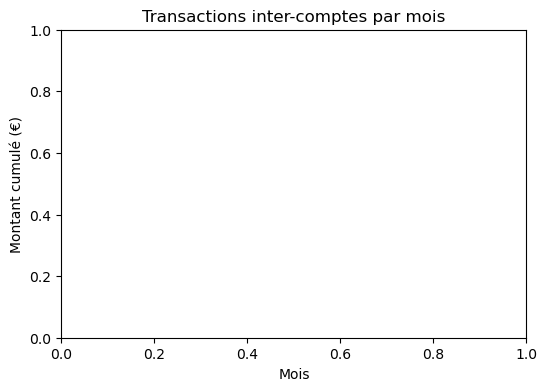

In [22]:
if __name__ == "__main__":
    app = MainApp("D:/Fichier/GitHub/Python_Budget/Notebook/CSV/liste.txt")
    app.mainloop()


# 

Probleme avec l'onglet ajout d'une transaction intercompte. En gros ce qu'il faudrait c'est directement changer le dataframe donc à refaire au propre